# Converting between Spyx and NIR

[NIR](https://neuroir.org) (the Neuromorphic Intermediate Representation) is a framework-agnostic format for spiking networks. Spyx can **export** a trained Flax-NNX model to a NIR graph and **import** a NIR graph produced by any other NIR-compatible tool (snnTorch, Norse, Sinabs, Lava, ...).

This notebook does a full round-trip on a small self-contained network so you can run it end to end with no external files:

1. build a tiny Spyx SNN and run it to get a reference output,
2. export it to a NIR graph and write that graph to disk,
3. read the graph back and re-import it with `spyx.nir.from_nir`, and
4. confirm the re-imported model reproduces the original output exactly.

In [1]:
import os
import tempfile

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import nir
from flax import nnx

import spyx
import spyx.nn as snn

/home/kade/Code/spyx/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Build a small SNN and run it

A two-layer spiking network: `Linear -> LIF -> Linear -> LIF`. NIR export supports the stateful neuron models (`LIF`, `CuBaLIF`, ...) and the `Linear` weights between them. `spyx.nn.run` scans the network over the time axis and expects **time-major** input of shape `(T, B, features)`.

In [2]:
rngs = nnx.Rngs(0)
model = snn.Sequential(
    nnx.Linear(16, 32, use_bias=False, rngs=rngs),
    snn.LIF((32,), beta=0.9, rngs=rngs),
    nnx.Linear(32, 10, use_bias=False, rngs=rngs),
    snn.LIF((10,), beta=0.8, rngs=rngs),
)

# Time-major input: 30 timesteps, batch of 4, 16 input channels of spikes.
x = jax.random.bernoulli(jax.random.PRNGKey(1), 0.5, (30, 4, 16)).astype(
    jnp.float32
)

reference_out, _ = snn.run(model, x)
print("input :", x.shape, " output:", reference_out.shape)
print("output spikes:", float(reference_out.sum()))

input : (30, 4, 16)  output: (30, 4, 10)
output spikes: 47.0


## Export the model to a NIR graph

`spyx.nir.to_nir` walks the NNX module and emits a `nir.NIRGraph`. You supply the input/output shapes (as `{name: shape}` dicts) and the time resolution `dt`. Spyx treats every timestep as `dt = 1` internally to stay unit-free, so pass the real `dt` here if you plan to load the graph into a simulator that works in physical time units. We then write the graph to disk with `nir.write`.

In [3]:
nir_graph = spyx.nir.to_nir(
    model, {"input": (16,)}, {"output": (10,)}, dt=1
)
print("NIR nodes:", list(nir_graph.nodes.keys()))
print("NIR edges:", nir_graph.edges)

# Persist it. Any NIR-compatible framework can now read this file.
path = os.path.join(tempfile.gettempdir(), "spyx_snn.nir")
nir.write(path, nir_graph)
print("wrote", path)

NIR nodes: ['input', 'output', 'layer_0', 'layer_1', 'layer_2', 'layer_3']
NIR edges: [('input', 'layer_0'), ('layer_0', 'layer_1'), ('layer_1', 'layer_2'), ('layer_2', 'layer_3'), ('layer_3', 'output')]
wrote /tmp/spyx_snn.nir


## Import a NIR graph back into Spyx

`spyx.nir.from_nir` is a *run-and-return* API: it rebuilds the model **and** runs it on the (time-major) input you pass, returning `(model, outputs)`. Reuse the returned `model` for further inference. Here we read the graph we just wrote and confirm the re-imported network reproduces the original output to floating-point tolerance -- which is exactly the portability guarantee NIR is meant to provide.

In [4]:
loaded_graph = nir.read(path)
imported_model, outputs = spyx.nir.from_nir(
    loaded_graph, x, dt=1, rngs=nnx.Rngs(1)
)

matches = bool(jnp.allclose(reference_out, outputs, atol=1e-5))
print("re-imported output shape:", outputs.shape)
print("matches original run:", matches)

re-imported output shape: (30, 4, 10)
matches original run: True


**Expected result:** `matches original run: True`. The round-trip is exact because every layer in this network has a NIR equivalent. Below we plot the output spike raster of the first sequence in the batch; the original and re-imported rasters are identical.

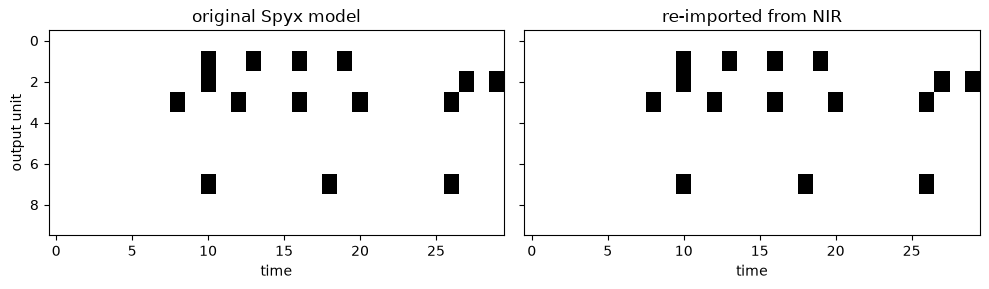

In [5]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
ax0.imshow(reference_out[:, 0].T, aspect="auto", cmap="Greys",
           interpolation="none")
ax0.set_title("original Spyx model")
ax0.set_xlabel("time"); ax0.set_ylabel("output unit")
ax1.imshow(outputs[:, 0].T, aspect="auto", cmap="Greys",
           interpolation="none")
ax1.set_title("re-imported from NIR")
ax1.set_xlabel("time")
plt.tight_layout()
plt.show()

## Notes

- **Supported layers.** Export covers `Linear` plus the spiking neuron models (`LIF`, `CuBaLIF`, and recurrent variants). A non-spiking leaky-integrator readout (`spyx.nn.LI`) has no NIR primitive and is skipped with a warning, so end a network you intend to export on a spiking layer.
- **`dt`.** Spyx assumes one timestep per step (`dt = 1`). When you import a graph trained in a simulator with a different `dt`, pass that value to `from_nir` so the neuron time constants are rescaled correctly.
- **Legacy param-dict export.** Older Spyx (Haiku era) exported from a parameter dictionary via `spyx.nir.reorder_layers(init_params, trained_params)` before calling `to_nir`. With the Flax-NNX API you pass the live model straight to `to_nir`, as shown above.
- **Interop.** See `docs/examples/nir/rsnn/braille_spyx.ipynb` for importing a recurrent SNN that was trained and exported from snnTorch.